In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
import time
import sys
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, losses, metrics
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## Loading Images

In [3]:
def load_images(filename):
    with gzip.open(filename, 'rb') as f:
        # The first 16 bytes are the header, which we skip
        f.read(16)
        # Read the rest of the bytes and reshape
        buffer = f.read()
        images = np.frombuffer(buffer, dtype=np.uint8).astype(np.float32)
        # Reshape to (number_of_images, 28, 28)
        images = images.reshape(-1, 28, 28)
        # Normalize the images to 0-1
        images = images / 255.0
    return images


In [4]:
def load_labels(filename):
    with gzip.open(filename, 'rb') as f:
        # The first 8 bytes are the header, which we skip
        f.read(8)
        # Read the rest of the bytes as labels
        buffer = f.read()
        labels = np.frombuffer(buffer, dtype=np.uint8)
    return labels


In [5]:
train_images = load_images('C:/Users/moins/Downloads/mnist/train-images-idx3-ubyte.gz')
train_labels = load_labels('C:/Users/moins/Downloads/mnist/train-labels-idx1-ubyte.gz')
test_images = load_images('C:/Users/moins/Downloads/mnist/t10k-images-idx3-ubyte.gz')
test_labels = load_labels('C:/Users/moins/Downloads/mnist/t10k-labels-idx1-ubyte.gz')


# Flatten the images for the neural network (28x28 -> 784)
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

print(f"Training data shape: {train_images.shape}, Training labels shape: {train_labels.shape}")
print(f"Testing data shape: {test_images.shape}, Testing labels shape: {test_labels.shape}")


Training data shape: (60000, 784), Training labels shape: (60000,)
Testing data shape: (10000, 784), Testing labels shape: (10000,)


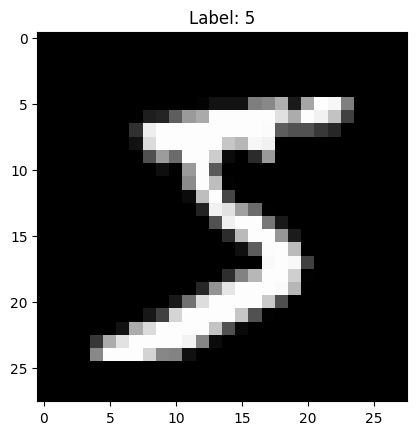

In [6]:
# Display a sample image and label
plt.imshow(train_images[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()


# Pure Python Approach

In [7]:
class SimpleNN:
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        # Initialize weights and biases using Xavier initialization
        self.weights1 = np.random.randn(input_size, hidden_size1) * np.sqrt(2. / input_size)
        self.bias1 = np.zeros((1, hidden_size1))

        self.weights2 = np.random.randn(hidden_size1, hidden_size2) * np.sqrt(2. / hidden_size1)
        self.bias2 = np.zeros((1, hidden_size2))

        self.weights3 = np.random.randn(hidden_size2, output_size) * np.sqrt(2. / hidden_size2)
        self.bias3 = np.zeros((1, output_size))

    def leaky_relu(self, x, alpha=0.01):
        return np.where(x > 0, x, x * alpha)

    def leaky_relu_derivative(self, x, alpha=0.01):
        dx = np.ones_like(x)
        dx[x < 0] = alpha
        return dx

    def softmax(self, x):
        exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)

    def forward(self, X):
        # Input layer to first hidden layer
        self.z1 = np.dot(X, self.weights1) + self.bias1
        self.a1 = self.leaky_relu(self.z1)

        # First hidden layer to second hidden layer
        self.z2 = np.dot(self.a1, self.weights2) + self.bias2
        self.a2 = self.leaky_relu(self.z2)

        # Second hidden layer to output layer
        self.z3 = np.dot(self.a2, self.weights3) + self.bias3
        self.a3 = self.softmax(self.z3)
        return self.a3

    def compute_loss(self, y_true, y_pred):
        # Number of samples
        n_samples = y_true.shape[0]
        # Calculate cross-entropy loss
        logp = -np.log(y_pred[range(n_samples), y_true])
        loss = np.sum(logp) / n_samples
        return loss

    def backward(self, X, y_true, y_pred, learning_rate):
        # Number of samples
        n_samples = X.shape[0]

        # Output layer error
        delta3 = y_pred
        delta3[range(n_samples), y_true] -= 1
        delta3 /= n_samples

        # Gradients for weights3 and bias3
        dw3 = np.dot(self.a2.T, delta3)
        db3 = np.sum(delta3, axis=0, keepdims=True)

        # Backpropagation to second hidden layer
        delta2 = np.dot(delta3, self.weights3.T) * self.leaky_relu_derivative(self.a2)

        # Gradients for weights2 and bias2
        dw2 = np.dot(self.a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)

        # Backpropagation to first hidden layer
        delta1 = np.dot(delta2, self.weights2.T) * self.leaky_relu_derivative(self.a1)

        # Gradients for weights1 and bias1
        dw1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # Update weights and biases
        self.weights1 -= learning_rate * dw1
        self.bias1 -= learning_rate * db1
        self.weights2 -= learning_rate * dw2
        self.bias2 -= learning_rate * db2
        self.weights3 -= learning_rate * dw3
        self.bias3 -= learning_rate * db3

    def train(self, X, y, epochs, learning_rate, batch_size=64):
        for epoch in range(epochs):
            indices = np.arange(X.shape[0])
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

            batch_loss = 0
            for start in range(0, X.shape[0], batch_size):
                end = start + batch_size
                X_batch, y_batch = X[start:end], y[start:end]

                # Forward propagation
                y_pred = self.forward(X_batch)
                # Compute loss
                loss = self.compute_loss(y_batch, y_pred)
                batch_loss += loss

                # Backward propagation
                self.backward(X_batch, y_batch, y_pred, learning_rate)

            avg_loss = batch_loss / (X.shape[0] // batch_size)
            # Print loss after each epoch
            print(f"Epoch {epoch+1}, Loss: {avg_loss}")

# Initialize model with input size = 784, hidden sizes, and output size = 10
input_size = 784  # 28x28 images
hidden_size1 = 256  # Increased number of neurons
hidden_size2 = 128  # Increased number of neurons
output_size = 10  # 10 digits

model = SimpleNN(input_size, hidden_size1, hidden_size2, output_size)

# Train the model
epochs = 10  # You can increase this for better accuracy
learning_rate = 0.005  # Reduced learning rate
batch_size = 64  # Batch size

model.train(train_images, train_labels, epochs, learning_rate, batch_size)

# Evaluate model accuracy
def calculate_accuracy(model, X, y):
    y_pred = model.forward(X)
    predictions = np.argmax(y_pred, axis=1)
    accuracy = np.mean(predictions == y)
    return accuracy

test_accuracy = calculate_accuracy(model, test_images, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Epoch 1, Loss: 1.0018345422845176
Epoch 2, Loss: 0.4262523065364246
Epoch 3, Loss: 0.3476746330867858
Epoch 4, Loss: 0.3104432843558048
Epoch 5, Loss: 0.2854735248253247
Epoch 6, Loss: 0.2668576626923491
Epoch 7, Loss: 0.25116992160202106
Epoch 8, Loss: 0.23746684610251748
Epoch 9, Loss: 0.2254001678336719
Epoch 10, Loss: 0.21481862758067463
Test Accuracy: 94.29%


## Its giving about 94% accuracy in classifying the images

# prediction - 10 digit classification - using pure python

In [8]:
# Prediction code for SimpleNN model

def predict_digits(model, X, y, num_samples=10):
    # Forward pass to get predictions
    predictions = model.forward(X)
    predicted_labels = np.argmax(predictions, axis=1)  # Get the predicted class labels

    # Display a few sample predictions
    indices = np.random.choice(len(X), num_samples, replace=False)

    print("Sample Predictions:")
    for i, idx in enumerate(indices):
        true_label = y[idx]
        pred_label = predicted_labels[idx]
        print(f"Sample {i+1}: True Label = {true_label}, Predicted Label = {pred_label}")

# Make predictions on test set and display sample predictions
predict_digits(model, test_images, test_labels)

Sample Predictions:
Sample 1: True Label = 3, Predicted Label = 3
Sample 2: True Label = 4, Predicted Label = 4
Sample 3: True Label = 4, Predicted Label = 4
Sample 4: True Label = 3, Predicted Label = 6
Sample 5: True Label = 9, Predicted Label = 9
Sample 6: True Label = 8, Predicted Label = 8
Sample 7: True Label = 1, Predicted Label = 1
Sample 8: True Label = 0, Predicted Label = 0
Sample 9: True Label = 1, Predicted Label = 1
Sample 10: True Label = 0, Predicted Label = 0


## Testing how are models working and its working well

# Pure python approach to predict if the number is odd or even

In [ ]:
# Convert labels to binary (1 for odd, 0 for even)
train_labels_odd_even = np.array([1 if label % 2 != 0 else 0 for label in train_labels])
test_labels_odd_even = np.array([1 if label % 2 != 0 else 0 for label in test_labels])

In [ ]:
# Fine-tuning model for odd/even classification
class SimpleNN_OddEven:
    def __init__(self, base_model):
        # Load the trained weights from the original model (feature extractor)
        self.base_model = base_model
        # Initialize new weights and biases for the odd/even classification layer
        self.weights_odd_even = np.random.randn(128, 2) * 0.01  # Matches second hidden layer size in `SimpleNN`
        self.bias_odd_even = np.zeros((1, 2))

    def leaky_relu(self, x, alpha=0.01):
        return np.where(x > 0, x, x * alpha)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Forward pass through the frozen base model up to the second hidden layer
        z1 = np.dot(X, self.base_model.weights1) + self.base_model.bias1
        a1 = self.leaky_relu(z1)

        z2 = np.dot(a1, self.base_model.weights2) + self.base_model.bias2
        a2 = self.leaky_relu(z2)

        # Skip the third layer of the original model and add the new odd/even classification layer
        z_odd_even = np.dot(a2, self.weights_odd_even) + self.bias_odd_even
        output = self.softmax(z_odd_even)
        return output

    def compute_loss(self, predictions, labels):
        n = labels.shape[0]
        correct_log_probs = -np.log(predictions[range(n), labels])
        loss = np.sum(correct_log_probs) / n
        return loss

    def backward(self, a2, labels, predictions, learning_rate=0.01):
        n = labels.shape[0]

        # Compute gradient for the softmax layer (output layer for odd/even classification)
        grad_output = predictions
        grad_output[range(n), labels] -= 1
        grad_output /= n

        # Gradient for weights and bias of the odd/even classification layer
        grad_weights_odd_even = np.dot(a2.T, grad_output)
        grad_biases_odd_even = np.sum(grad_output, axis=0, keepdims=True)

        # Update only the weights and biases for the new layer
        self.weights_odd_even -= learning_rate * grad_weights_odd_even
        self.bias_odd_even -= learning_rate * grad_biases_odd_even

    def train(self, X, y, epochs=10, learning_rate=0.01, batch_size=64):
        for epoch in range(epochs):
            indices = np.arange(X.shape[0])
            np.random.shuffle(indices)
            X = X[indices]
            y = y[indices]

            batch_loss = 0
            for start in range(0, X.shape[0], batch_size):
                end = start + batch_size
                X_batch, y_batch = X[start:end], y[start:end]

                # Forward pass
                predictions = self.forward(X_batch)
                loss = self.compute_loss(predictions, y_batch)
                batch_loss += loss

                # Backward pass
                # Run forward pass through the frozen base model to get `a2`
                z1 = np.dot(X_batch, self.base_model.weights1) + self.base_model.bias1
                a1 = self.leaky_relu(z1)
                z2 = np.dot(a1, self.base_model.weights2) + self.base_model.bias2
                a2 = self.leaky_relu(z2)

                self.backward(a2, y_batch, predictions, learning_rate)

            avg_loss = batch_loss / (X.shape[0] // batch_size)
            print(f"Epoch {epoch+1}, Loss: {avg_loss}")

# Initialize and train the odd/even model
odd_even_model = SimpleNN_OddEven(model)
epochs = 2
learning_rate = 0.01

odd_even_model.train(train_images, train_labels_odd_even, epochs, learning_rate)

# Evaluate the odd/even model accuracy
def calculate_accuracy_odd_even(model, X, y):
    y_pred = model.forward(X)
    predictions = np.argmax(y_pred, axis=1)
    accuracy = np.mean(predictions == y)
    return accuracy

odd_even_accuracy = calculate_accuracy_odd_even(odd_even_model, test_images, test_labels_odd_even)
print(f"Odd/Even Classification Test Accuracy: {odd_even_accuracy * 100:.2f}%")


Epoch 1, Loss: 0.2812201437273927
Epoch 2, Loss: 0.23288947755511888
Odd/Even Classification Test Accuracy: 91.48%


## Its giving an accuracy of 92% for classifying odd/even

# Prediction of odd or even

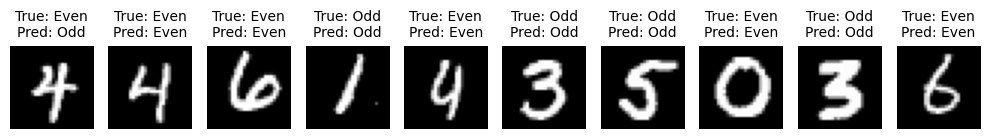

In [ ]:
import matplotlib.pyplot as plt

# Function to make predictions and display results with images
def predict_odd_even_with_images(model, X, y, num_samples=10):
    predictions = model.forward(X)  # Generate predictions
    predicted_labels = np.argmax(predictions, axis=1)  # Convert predictions to class labels (0: Even, 1: Odd)

    # Randomly select a few samples to display
    indices = np.random.choice(len(X), num_samples, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        true_label = "Odd" if y[idx] == 1 else "Even"
        pred_label = "Odd" if predicted_labels[idx] == 1 else "Even"

        # Reshape the image back to 28x28 for visualization (assuming the images are 28x28 pixels)
        image = X[idx].reshape(28, 28)

        # Plot the image
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)

    plt.tight_layout()
    plt.show()

# Make predictions on test set and display sample predictions with images
predict_odd_even_with_images(odd_even_model, test_images, test_labels_odd_even)


## Segregating the number in 3 classes stick-like, curly, and round-like to classify them using VGG 16

In [ ]:
import numpy as np

# Original MNIST digit labels (0 to 9)
# Group them into the three new classes: stick-like, curly, and round-like

def reclassify_labels(labels):
    # Initialize an empty array for new labels
    new_labels = np.zeros_like(labels)

    for i, label in enumerate(labels):
        if label in [1, 4, 7]:  # Stick-like
            new_labels[i] = 0
        elif label in [2, 3, 5]:  # Curly
            new_labels[i] = 1
        elif label in [0, 6, 8, 9]:  # Round-like
            new_labels[i] = 2
    return new_labels

# Apply this reclassification to your train and test labels
train_labels_reclassified = reclassify_labels(train_labels)
test_labels_reclassified = reclassify_labels(test_labels)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Load and preprocess the dataset (assuming MNIST-like 28x28 grayscale images)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Resize images to 32x32 and expand to 3 channels for VGG16 compatibility
train_images_resized = tf.image.resize(train_images[..., tf.newaxis], [32, 32])  # Add a channel dimension
test_images_resized = tf.image.resize(test_images[..., tf.newaxis], [32, 32])

# Convert grayscale images to RGB (3 channels)
train_images_rgb = tf.image.grayscale_to_rgb(train_images_resized)
test_images_rgb = tf.image.grayscale_to_rgb(test_images_resized)

# Normalize pixel values
train_images_rgb = train_images_rgb / 255.0
test_images_rgb = test_images_rgb / 255.0

# Reclassify labels into three classes: stick-like, curly, and round-like digits
stick_like_digits = [1, 4, 7]
curly_digits = [2, 3, 5]
round_like_digits = [0, 6, 8, 9]

# Map each digit to a new label
train_labels_reclassified = [0 if label in stick_like_digits else 1 if label in curly_digits else 2 for label in train_labels]
test_labels_reclassified = [0 if label in stick_like_digits else 1 if label in curly_digits else 2 for label in test_labels]

# Convert labels to one-hot encoding for categorical cross-entropy
train_labels_one_hot = to_categorical(train_labels_reclassified, 3)
test_labels_one_hot = to_categorical(test_labels_reclassified, 3)

# Load VGG16 without the top layers and freeze the base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
for layer in base_model.layers:
    layer.trainable = False

# Create a new model with custom classification layers
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')  # 3 output classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images_rgb, train_labels_one_hot, epochs=2, batch_size=64, validation_data=(test_images_rgb, test_labels_one_hot))

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_rgb, test_labels_one_hot, verbose=2)
print(f"Test accuracy: {test_acc * 100:.2f}%")


Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 852s 907ms/step - accuracy: 0.8917 - loss: 0.2783 - val_accuracy: 0.9683 - val_loss: 0.0924
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 823s 878ms/step - accuracy: 0.9635 - loss: 0.1043 - val_accuracy: 0.9680 - val_loss: 0.0891
313/313 - 115s - 368ms/step - accuracy: 0.9680 - loss: 0.0891
Test accuracy: 96.80%


## Its giving a 96% accuracy by classifying them in 3 classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 145s 463ms/step


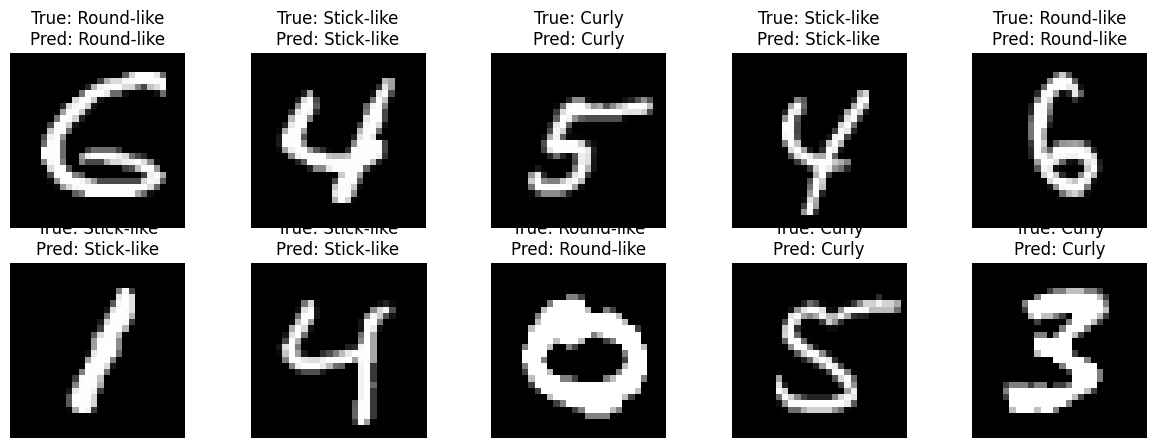

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Class labels for the three categories
class_names = ["Stick-like", "Curly", "Round-like"]

# Make predictions on the test set
predictions = model.predict(test_images_rgb)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Display a few sample predictions
num_samples = 10  # Number of samples to display
indices = np.random.choice(len(test_images_rgb), num_samples, replace=False)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[idx], cmap='gray')
    plt.axis('off')
    true_label = class_names[np.argmax(test_labels_one_hot[idx])]
    pred_label = class_names[predicted_labels[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")

plt.show()


# VGG - 16

# Professor Notebook pure python VGG approach

In [9]:
class NeuralNetworkModule:
    def forward(self, x):
        pass

    def backward(self, dy):
        pass

    def predict(self, x):
        return self.forward(x)

In [10]:
class OptimizableModule(NeuralNetworkModule):
    # Should fill w and dw in subclasses
    def __init__(self):
        self.optimizer = None
        self.w = None
        self.dw = None

    def update(self):
        step = self.optimizer.step(self.dw)
        self.w -= step

In [11]:
class OptimizableModule(NeuralNetworkModule):
    # Should fill w and dw in subclasses
    def __init__(self):
        self.optimizer = None
        self.w = None
        self.dw = None

    def update(self):
        step = self.optimizer.step(self.dw)
        self.w -= step

In [12]:
class SigmoidModule(NeuralNetworkModule):
    # Sigmoid Layer: y = 1 / (1 + e^(-x))
    def __init__(self):
        self.y = None

    def forward(self, x):
        self.y = 1 / (1 + np.exp(-x))
        return self.y

    def backward(self, dy):
        dx = dy * self.y * (1 - self.y)
        return dx

class ReluModule(NeuralNetworkModule):
    # ReLU Layer: y = 0, x<0; x, x>=0
    def __init__(self):
        self.x = None

    def forward(self, x):
        self.x = x
        y = x.copy()
        y[x < 0] = 0
        return y

    def backward(self, dy):
        d = np.ones_like(self.x)
        d[self.x < 0] = 0
        return d * dy

In [13]:
class SequentialNeuralNetwork:
    def __init__(self, sequential, loss_func, optimizer):
        self.sequential = sequential
        self.loss_func = loss_func
        self.set_optimizer(optimizer)

    def forward(self, x):
        h = x
        for layer in self.sequential:
            h = layer.forward(h)
        return h

    def backward(self, dy):
        dh = dy
        for layer in reversed(self.sequential):
            dh = layer.backward(dh)

    def update(self):
        for layer in self.sequential:
            if isinstance(layer, OptimizableModule):
                layer.update()

    def set_optimizer(self, optimizer):
        for layer in self.sequential:
            if isinstance(layer, OptimizableModule):
                layer.optimizer = copy.copy(optimizer)

    def train(self, x, y):
        y_hat = self.forward(x)
        (loss, dy) = self.loss_func(y_hat, y)
        self.backward(dy)
        self.update()
        return loss

    def predict(self, x):
        h = x
        for layer in self.sequential:
            h = layer.predict(h)
        y_hat = h
        return np.argmax(y_hat, 1)

In [14]:
class ConvolutionModule(OptimizableModule):
    # should satisfy: 2p + x - w == (y - 1) * s
    def __init__(self, num_channels_in, num_channels_out, window_size, padding, stride=(1, 1), random=True):
        # weight_size: [height, width]
        super().__init__()
        # unrolled weight

        self.window_size = window_size
        self.stride = stride
        self.padding = padding
        self.y_width = 0
        self.y_height = 0
        self.zero_image_shape = None
        self.weight_size = (window_size[0] * window_size[1] * (num_channels_in + 1), num_channels_out)
        self.num_channels_in = num_channels_in
        self.num_channels_out = num_channels_out

        if random:
            std_v = 1. / np.sqrt(np.prod(self.weight_size) * num_channels_in)
            self.w = np.random.uniform(-std_v, std_v, self.weight_size)
        else:
            self.w = np.zeros(self.weight_size)

        self.dw = np.zeros_like(self.w)
        self.x1p = None

    def batch_unroll(self, x, weight_size, stride):
        # x is a 4d tensor([batch_size, height, width, channels])
        unrolled_x, y_height, y_width = batch_image_unroll(x, weight_size, stride)
        self.zero_image_shape = x.shape
        self.y_width, self.y_height = y_width, y_height
        return unrolled_x

    def batch_roll(self, unrolled_x, weight_size, stride):
        # unrolled_x is a 3d tensor([batch_size, y_height * y_width, w_height * w_width * channels])
        y_width, y_height = self.y_width, self.y_height
        num_channels = self.num_channels_in + 1
        x = batch_image_roll(unrolled_x, self.zero_image_shape, weight_size, stride, y_height, y_width, num_channels)
        return x

    @staticmethod
    def batch_matmul(x, w):
        return einsum('ijk,kh->ijh', x, w)

    def batch_convolve(self, x, w):
        # x is bias-included, batched, unrolled input
        # w is unrolled kernel
        y = self.batch_matmul(x, w)
        return y

    def forward(self, x):
        # x_size = [batch_size, height, width, num_channels_in]
        assert len(x.shape) == 4
        num_samples, x_height, x_width = x.shape[0], x.shape[1], x.shape[2]
        x_1 = np.pad(x, ((0, 0), (0, 0), (0, 0), (0, 1)), 'constant', constant_values=1)
        x_1_p = np.pad(x_1, ((0, 0), (self.padding[0], self.padding[0]),
                             (self.padding[1], self.padding[1]), (0, 0)), 'constant', constant_values=0)
        unrolled_x1p = self.batch_unroll(x_1_p, self.window_size, self.stride)
        self.x1p = unrolled_x1p
        unrolled_y = self.batch_convolve(self.x1p, self.w)
        y = unrolled_y.reshape([num_samples, self.y_height, self.y_width, self.num_channels_out])
        return y

    def backward(self, dy):
        num_samples, y_height, y_width = dy.shape[0], dy.shape[1], dy.shape[2]
        dy_unrolled = dy.reshape([num_samples, y_height * y_width, self.num_channels_out])
        dw = einsum('ijk,ikh->jh', np.transpose(self.x1p, axes=(0, 2, 1)), dy_unrolled)
        self.dw = dw / num_samples
        dx1p_unrolled = self.batch_matmul(dy_unrolled, np.transpose(self.w))
        dx1p = self.batch_roll(dx1p_unrolled, self.window_size, self.stride)
        dx1 = dx1p[:, self.padding[0]:-self.padding[0], self.padding[1]:-self.padding[1], :]
        return dx1[:, :, :, :-1]

In [15]:
class DropoutModule(NeuralNetworkModule):
    def __init__(self, p):
        self.keep_prob = 1-p
        self.mask = None

    def forward(self, x):
        self.mask = np.random.binomial(1, self.keep_prob, size=x.shape)
        y = x * self.mask / self.keep_prob
        return y

    def backward(self, dy):
        dx = dy * self.mask * self.keep_prob
        return dx

    def predict(self, x):
        return x

In [16]:
class MaxPoolModule(NeuralNetworkModule):
    def __init__(self, window_size, stride):
        self.window_size = window_size
        self.stride = stride
        self.mask = None
        self.y_height = 0
        self.y_width = 0
        self.output_size = 0
        self.zero_image_shape = None

    def forward(self, x):
        num_samples, num_channels = x.shape[0], x.shape[3]
        unrolled_x, y_height, y_width = batch_image_unroll(x, self.window_size, self.stride)
        self.zero_image_shape = x.shape
        self.output_size = num_samples * y_height * y_width * num_channels
        unrolled_x = unrolled_x.reshape([num_samples, y_height * y_width, np.prod(self.window_size), num_channels])
        unrolled_x_ = np.transpose(unrolled_x, axes=(0, 1, 3, 2)). \
            reshape(self.output_size, np.prod(self.window_size))
        y = np.max(unrolled_x, axis=2).reshape([num_samples, y_height, y_width, num_channels])
        self.mask = np.argmax(unrolled_x_, axis=1)
        self.y_height, self.y_width = y_height, y_width
        return y

    def backward(self, dy):
        # dy is a batched gradients with size [num_samples, y_height, y_width, num_channels]
        num_samples, y_height, y_width, num_channels = dy.shape[0], dy.shape[1], dy.shape[2], dy.shape[3]
        dy_unrolled = dy.reshape([num_samples, y_height * y_width, 1, num_channels])
        dx_unrolled_ = np.zeros([self.output_size, np.prod(self.window_size)])
        dx_unrolled_[np.arange(self.output_size), self.mask] = dy_unrolled.ravel()
        dx_unrolled = np.transpose(dx_unrolled_.reshape(
            [num_samples, y_height * y_width, num_channels, np.prod(self.window_size)]), axes=(0, 1, 3, 2))
        dx_unrolled = dx_unrolled.reshape([num_samples, y_height * y_width, np.prod(self.window_size) * num_channels])
        dx = batch_image_roll(dx_unrolled, self.zero_image_shape,
                              self.window_size, self.stride, y_height, y_width, num_channels)
        return dx

In [17]:
class LinearModule(OptimizableModule):
    # Linear Layer: Y = W * [X, 1]
    def __init__(self, input_size, output_size, random=True):
        super().__init__()
        if random:
            std_v = 1. / np.sqrt(input_size)
            self.w = (np.random.uniform(-std_v, std_v, [input_size + 1, output_size]))
        else:
            self.w = np.zeros([input_size + 1, output_size])

        self.dw = None
        self.x_1 = None
        self.input_shape = None
        self.input_size = input_size

    def forward(self, x):
        num_samples = x.shape[0]
        self.input_shape = x.shape
        if len(x.shape) > 2:
            # Squeezing
            x = x.reshape(num_samples, self.input_size)
        self.x_1 = np.concatenate([x, np.ones([num_samples, 1])], axis=1) #flatten and add bias
        y = matmul(self.x_1, self.w)
        return y

    def backward(self, dy):
        self.dw = einsum('ij,ih->hj', dy, self.x_1) / dy.shape[0]
        dx = matmul(dy, np.transpose(self.w))[:, :-1]
        dx = dx.reshape(self.input_shape)
        return dx

In [18]:
class MeanSquaredError:
    def __call__(self, y_hat, y):
        # return Loss & Derivative
        return np.mean((y - y_hat) ** 2) / 2, y_hat - y


class CrossEntropyLoss:
    def __call__(self, y_hat, y):
        y_prob = softmax(y_hat)
        # return Loss & Derivative
        return np.sum(- np.log(y_prob) * y), y_prob - y

In [19]:
class Adam:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.alpha = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = 0
        self.v = 0
        self.t = 0

    def step(self, dw):
        self.t += 1
        g = dw
        m = (self.beta1 * self.m + (1 - self.beta1) * g)
        v = (self.beta2 * self.v + (1 - self.beta2) * g ** 2)
        alpha = self.alpha * np.sqrt(1 - self.beta2 ** self.t) / (1 - self.beta1 ** self.t)
        dw = alpha * m / (np.sqrt(v) + self.eps)
        self.m = m
        self.v = v
        return dw

In [20]:
def batch_image_unroll(img, weight_size, stride):
    # img input is a 4d tensor([batch_size, height, width, channels])
    w_height, w_width = weight_size[0], weight_size[1]
    s_height, s_width = stride[0], stride[1]
    num_samples, x_height, x_width, num_channels = img.shape[0], img.shape[1], img.shape[2], img.shape[3]
    y_height, y_width = (x_height - w_height) // s_height + 1, (x_width - w_width) // s_width + 1

    unrolled_img = np.zeros([num_samples, y_height, y_width, w_height, w_width, num_channels])
    for y in range(w_height):
        y_max = y + s_height * y_height
        for x in range(w_width):
            x_max = x + s_width * y_width
            unrolled_img[:, :, :, y, x, :] = img[:, y:y_max:s_height, x:x_max:s_width, :]

    unrolled_img = unrolled_img.reshape([num_samples, y_height * y_width, w_height * w_width * num_channels])
    return unrolled_img, y_height, y_width

def batch_image_roll(unrolled_img, zero_image_shape, weight_size, stride, y_height, y_width, num_channels):
    # unrolled_x is a 3d tensor([batch_size, y_height * y_width, w_height * w_width * channels])
    num_samples = unrolled_img.shape[0]
    w_height, w_width = weight_size[0], weight_size[1]
    s_height, s_width = stride[0], stride[1]
    unrolled_img = unrolled_img.reshape([num_samples, y_height, y_width, w_height, w_width, num_channels])

    img = np.zeros(zero_image_shape)
    for y in range(w_height):
        y_max = y + s_height * y_height
        for x in range(w_width):
            x_max = x + s_width * y_width
            img[:, y:y_max:s_height, x:x_max:s_width, :] += unrolled_img[:, :, :, y, x, :]

    return img

In [21]:
hidden_size = 512

class ConvNetwork(SequentialNeuralNetwork):
    def __init__(self, output_size):
        sequential = list()
        sequential.append(ConvolutionModule(1, 32, window_size=(5, 5), stride=(1, 1), padding=(2, 2)))
        sequential.append(ReluModule())
        sequential.append(MaxPoolModule(window_size=(2, 2), stride=(2, 2)))
        sequential.append(DropoutModule(p=0.15))
        sequential.append(ConvolutionModule(32, 64, window_size=(3, 3), stride=(1, 1), padding=(1, 1)))
        sequential.append(ReluModule())
        sequential.append(MaxPoolModule(window_size=(2, 2), stride=(2, 2)))
        sequential.append(DropoutModule(p=0.15))

        sequential.append(LinearModule(7 * 7 * 64, hidden_size))
        sequential.append(ReluModule())
        sequential.append(LinearModule(hidden_size, hidden_size))
        sequential.append(ReluModule())
        sequential.append(DropoutModule(p=0.25))
        sequential.append(LinearModule(hidden_size, hidden_size))
        sequential.append(ReluModule())
        sequential.append(LinearModule(hidden_size, hidden_size))
        sequential.append(ReluModule())
        sequential.append(DropoutModule(p=0.25))
        sequential.append(LinearModule(hidden_size, output_size))

        loss_func = CrossEntropyLoss()
        optimizer = Adam(lr=1e-3)
        super().__init__(sequential, loss_func, optimizer)

In [22]:
def _read32(bytestream):
    dt = np.dtype(np.uint32).newbyteorder('>')
    return np.frombuffer(bytestream.read(4), dtype=dt)[0]

def extract_images(filename):
    """Extract the images into a 4D uint8 numpy array [index, y, x, depth]."""
    print('Extracting', filename)
    with gzip.open(filename) as bytestream:
        magic = _read32(bytestream)
        if magic != 2051:
            raise ValueError(
                'Invalid magic number %d in MNIST image file: %s' %
                (magic, filename))
        num_images = _read32(bytestream)
        rows = _read32(bytestream)
        cols = _read32(bytestream)
        buf = bytestream.read(rows * cols * num_images)
        data = np.frombuffer(buf, dtype=np.uint8)
        data = data.reshape(num_images, rows, cols, 1)
        return data

def dense_to_one_hot(labels_dense, num_classes=10):
    """Convert class labels from scalars to one-hot vectors."""
    num_labels = labels_dense.shape[0]
    index_offset = np.arange(num_labels) * num_classes
    labels_one_hot = np.zeros((num_labels, num_classes))
    labels_one_hot.flat[index_offset + labels_dense.ravel()] = 1
    return labels_one_hot

def encode_one_hot(y):
    _num_samples = len(y)
    _num_classes = np.max(y) + 1
    _y_01 = np.zeros([_num_samples, _num_classes])
    _y_01[np.arange(0, y.shape[0]), y.ravel()] = 1
    return _y_01

def extract_labels(filename, one_hot=False):
    """Extract the labels into a 1D uint8 numpy array [index]."""
    print('Extracting', filename)
    with gzip.open(filename) as bytestream:
        magic = _read32(bytestream)
        if magic != 2049:
            raise ValueError(
                'Invalid magic number %d in MNIST label file: %s' %
                (magic, filename))
        num_items = _read32(bytestream)
        buf = bytestream.read(num_items)
        labels = np.frombuffer(buf, dtype=np.uint8)
        if one_hot:
            return dense_to_one_hot(labels)
        return labels


def read_data_sets(data_dir, one_hot=False, dtype=np.float32, val_size=5000):

    TRAIN_IMAGES = 'train-images-idx3-ubyte.gz'
    TRAIN_LABELS = 'train-labels-idx1-ubyte.gz'
    TEST_IMAGES = 't10k-images-idx3-ubyte.gz'
    TEST_LABELS = 't10k-labels-idx1-ubyte.gz'

    VALIDATION_SIZE = val_size
    local_file = os.path.join(data_dir, TRAIN_IMAGES)
    train_images = extract_images(local_file)
    local_file = os.path.join(data_dir, TRAIN_LABELS)
    train_labels = extract_labels(local_file, one_hot=one_hot)
    local_file = os.path.join(data_dir, TEST_IMAGES)
    test_images = extract_images(local_file)
    local_file = os.path.join(data_dir, TEST_LABELS)

    test_labels = extract_labels(local_file, one_hot=one_hot)
    validation_images = train_images[:VALIDATION_SIZE]
    validation_labels = train_labels[:VALIDATION_SIZE]
    train_images = train_images[VALIDATION_SIZE:]
    train_labels = train_labels[VALIDATION_SIZE:]
    train = [train_images / 255.0, train_labels]
    valid = [validation_images / 255.0, validation_labels]
    test = [test_images / 255.0, test_labels]

    return train, valid, test

In [23]:
batch_size = 100
display_size = 10000
shuffle = True
seed = 20210527

f0 = sys.stdout
f = open('C:/Users/moins/Downloads/' + "batch_size{}_seed{}_console_rec.txt".format(batch_size, seed), 'w')
sys.stdout = f0

# Set Seed
np.random.seed(seed)

# read data
train_data, _, test_data = read_data_sets('C:/Users/moins/Downloads/', val_size=0)
x_train, x_test = train_data[0] * 2 - 1, test_data[0] * 2 - 1
y_train, y_test = train_data[1], test_data[1]

Extracting /content/train-images-idx3-ubyte.gz
Extracting /content/train-labels-idx1-ubyte.gz
Extracting /content/t10k-images-idx3-ubyte.gz
Extracting /content/t10k-labels-idx1-ubyte.gz


In [24]:
x_train.shape, y_train.shape

((60000, 28, 28, 1), (60000,))

In [25]:
x_test.shape, y_test.shape

((10000, 28, 28, 1), (10000,))

In [26]:
# access data size: num_samples & num_features
num_samples, height, width, num_channels = x_train.shape
num_features = height * width
num_classes = 10

# Initialize
# model = LinearNetwork(num_features, num_classes)
model = ConvNetwork(num_classes)

# encode one-hot vector
y_01 = encode_one_hot(y_train)

num_batches = num_samples // batch_size

In [27]:
einsum = np.einsum
matmul = np.matmul

In [28]:
def softmax(z):
    num_classes = z.shape[1]
    zk = np.expand_dims(z, 2).repeat(num_classes, axis=2)
    zi = np.expand_dims(z, 1).repeat(num_classes, axis=1)
    ret = zi - zk
    ret = 1 / np.sum(np.exp(ret), axis=2)
    return ret

In [30]:
#num_epochs = 20
num_epochs = 1
start = time.time()

for epoch in range(num_epochs):
    loss = 0
    if shuffle:
        shuffle_indices = np.random.permutation(np.arange(num_samples))
        x_train = x_train[shuffle_indices, :]
        y_01 = y_01[shuffle_indices, :]

    for batch in range(num_batches):
        batch_idc = range(batch * batch_size, (batch + 1) * batch_size)
        loss += model.train(x_train[batch_idc, :], y_01[batch_idc, :])
        if ((batch+1) * batch_size) % display_size == 0:
            print('Epoch [{}/{}], Sample [{}/{}], Loss: {:.5f}'
                  .format(epoch + 1, num_epochs, (batch+1) * batch_size, num_samples, loss/display_size))
            loss = 0


end = time.time()
print('Training Time:{} seconds'.format(end - start))

Epoch [1/1], Sample [10000/60000], Loss: 0.33704
Epoch [1/1], Sample [20000/60000], Loss: 0.17914
Epoch [1/1], Sample [30000/60000], Loss: 0.13129
Epoch [1/1], Sample [40000/60000], Loss: 0.13961
Epoch [1/1], Sample [50000/60000], Loss: 0.11594
Epoch [1/1], Sample [60000/60000], Loss: 0.09868
Training Time:987.0259256362915 seconds


# **Tensor flow VGG 16 approach**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import models, layers, optimizers, losses, metrics
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.summary()

C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.datasets import mnist  # Import the mnist module

(train_images, train_labels), (test_images, test_labels) = mnist.load_data() # Now mnist is defined and can be used

In [5]:
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

In [6]:
test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

In [7]:

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [8]:
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(train_images, train_labels, epochs=6, batch_size=64)

Epoch 1/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8698 - loss: 0.4063
Epoch 2/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9844 - loss: 0.0505
Epoch 3/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9905 - loss: 0.0313
Epoch 4/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9921 - loss: 0.0245
Epoch 5/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9947 - loss: 0.0168
Epoch 6/6
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9957 - loss: 0.0133


In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test_loss:', test_loss)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9894 - loss: 0.0361
test_loss: 0.02801988273859024
test_acc: 0.9914000034332275


## Hence we can conclude that with the pure python approach we can achieve classification accuracy of about 92% for classifying 10 digits and 95% accuracy of classifying Odd/Even digits and 96% accuracy in dividing them in 3-classes.